# Análisis Exporatorio de los datos de un año entero

### 0. Importación de Librerías y Configuración

In [2]:
import pandas as pd
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

### 1. Carga y Configuración de Datos

In [3]:
BASE_DIR = "../../data/processed/tlc_clean"
ANIO = "2025" 
SAMPLE_RATE = 0.10  # 10% de cada mes

In [25]:
# 1. Definir la ruta del archivo (ajusta el nombre al tuyo)
ruta_archivo = "../../data/processed/tlc_clean/yellow/2025/clean_yellow_tripdata_2025-01.parquet"

# 2. Leer el archivo Parquet
df = pd.read_parquet(ruta_archivo)

# 3. Comprobaciones rápidas
print(f"Dataset cargado con {len(df):,} filas.")
print("\nPrimeras 5 filas:")
display(df.head())
print("\nUltimas 5 filas:")
display(df.tail())

# 4. Ver qué columnas tiene (basado en vuestro análisis previo)
print("\nColumnas disponibles:")
print(df.columns.tolist())

Dataset cargado con 2,801,473 filas.

Primeras 5 filas:


,fecha_inicio,fecha_fin,origen_id,destino_id,num_pasajeros,distancia,duracion_min,velocidad_mph,tipo_vehiculo,precio_base,...,origen_barrio,destino_zona,destino_barrio,temp_c,precipitation,viento_kmh,lluvia,nieve,es_festivo,hay_evento
0,2025-01-01 00:00:00,2025-01-01 01:03:09,211,164,1,6.40,63.150000,6.080760,yellow,52.0,...,Manhattan,Midtown South,Manhattan,8.2,0.9,14.9,1,0,1,1
1,2025-01-01 00:00:02,2025-01-01 00:09:36,237,262,1,1.71,9.566667,10.724739,yellow,11.4,...,Manhattan,Yorkville East,Manhattan,8.2,0.9,14.9,1,0,1,1
2,2025-01-01 00:00:03,2025-01-01 00:07:46,107,114,2,1.20,7.716667,9.330454,yellow,9.3,...,Manhattan,Greenwich Village South,Manhattan,8.2,0.9,14.9,1,0,1,1
3,2025-01-01 00:00:07,2025-01-01 00:06:31,148,45,1,0.93,6.400000,8.718750,yellow,7.9,...,Manhattan,Chinatown,Manhattan,8.2,0.9,14.9,1,0,1,1
4,2025-01-01 00:00:17,2025-01-01 00:15:22,132,10,1,5.60,15.083333,22.276243,yellow,22.6,...,Queens,Baisley Park,Queens,9.2,3.8,9.3,1,0,1,1



Ultimas 5 filas:


,fecha_inicio,fecha_fin,origen_id,destino_id,num_pasajeros,distancia,duracion_min,velocidad_mph,tipo_vehiculo,precio_base,...,origen_barrio,destino_zona,destino_barrio,temp_c,precipitation,viento_kmh,lluvia,nieve,es_festivo,hay_evento
2801468,2025-01-31 23:59:54,2025-02-01 00:12:32,261,249,1,2.02,12.633333,9.593667,yellow,13.500000,...,Manhattan,West Village,Manhattan,-1.8,0.0,10.8,0,0,0,0
2801469,2025-01-31 23:59:56,2025-02-01 00:19:41,237,79,2,3.34,19.750000,10.146835,yellow,19.799999,...,Manhattan,East Village,Manhattan,-1.8,0.0,10.8,0,0,0,0
2801470,2025-01-31 23:59:57,2025-02-01 00:07:11,163,237,1,1.37,7.233333,11.364055,yellow,9.300000,...,Manhattan,Upper East Side South,Manhattan,-1.8,0.0,10.8,0,0,0,0
2801471,2025-01-31 23:59:58,2025-02-01 00:25:31,161,148,1,3.40,25.550000,7.984345,yellow,23.299999,...,Manhattan,Lower East Side,Manhattan,-1.8,0.0,10.8,0,0,0,0
2801472,2025-01-31 23:59:59,2025-02-01 00:14:17,107,140,1,3.32,14.300000,13.930070,yellow,18.400000,...,Manhattan,Lenox Hill East,Manhattan,-1.8,0.0,10.8,0,0,0,0



Columnas disponibles:
['fecha_inicio', 'fecha_fin', 'origen_id', 'destino_id', 'num_pasajeros', 'distancia', 'duracion_min', 'velocidad_mph', 'tipo_vehiculo', 'precio_base', 'precio_total_est', 'espera_min', 'origen_zona', 'origen_barrio', 'destino_zona', 'destino_barrio', 'temp_c', 'precipitation', 'viento_kmh', 'lluvia', 'nieve', 'es_festivo', 'hay_evento']


In [13]:
# --- FUNCIÓN DE CARGA ---

def carga_datos_todosmeses():
    lista_muestras = []
    
    # Iteramos por los dos tipos de servicio que menciona el contexto: Yellow y VTC
    for tipo in ['yellow', 'fhvhv']:
        ruta_busqueda = os.path.join(BASE_DIR, tipo, ANIO, "*.parquet")
        archivos_meses = sorted(glob.glob(ruta_busqueda))
        
        if not archivos_meses:
            print(f"No se encontraron archivos para {tipo} en {ANIO}")
            continue
            
        print(f"Procesando {len(archivos_meses)} meses de {tipo}...")
        
        for archivo in archivos_meses:
            # 1. Leer el archivo del mes completo
            df_mes = pd.read_parquet(archivo)
            
            # 2. Extraer el 10% de forma aleatoria pero reproducible
            df_sample = df_mes.sample(frac=SAMPLE_RATE, random_state=42)
            
            # 3. Añadir etiquetas para no perder la información al unir
            df_sample['tipo_vehiculo'] = 'Yellow Taxi' if tipo == 'yellow' else 'VTC'
            
            # Aseguramos que la fecha sea datetime y extraemos el mes
            df_sample['fecha_inicio'] = pd.to_datetime(df_sample['fecha_inicio'])
            df_sample['mes_num'] = df_sample['fecha_inicio'].dt.month
            
            lista_muestras.append(df_sample)
            print(f"Mes {df_sample['mes_num'].iloc[0]} cargado ({len(df_sample):,} registros)")

    # 4. Concatenar todas las muestras en un único DataFrame
    df_final = pd.concat(lista_muestras, ignore_index=True)
    
    # 5. Ordenar por mes y tipo para que las gráficas salgan perfectas
    df_final = df_final.sort_values(by=['mes_num', 'tipo_vehiculo'])
    
    # Resetear el índice para que sea limpio
    df_final = df_final.reset_index(drop=True)
    
    print(f"\nProceso finalizado. Dataset creado con {len(df_final):,} filas totales.")
    return df_final

In [ ]:
# Ejecución
df_anual = carga_datos_todosmeses()
print("\nPrimeras 5 filas:")
display(df_anual.head())
print("\nUltimas 5 filas:")
display(df_anual.tail())
# Guardar el resultado para no tener que repetir el proceso cada vez que abras el notebook
# df_anual.to_parquet("df_ny_2025_sample_10pct.parquet")


Procesando 2 meses de yellow...
Mes 1 cargado (280,147 registros)
Mes 2 cargado (264,376 registros)
Procesando 2 meses de fhvhv...
Mes 1 cargado (1,460,435 registros)
Mes 2 cargado (1,368,289 registros)

Proceso finalizado. Dataset creado con 3,373,247 filas totales.


,fecha_inicio,fecha_fin,origen_id,destino_id,num_pasajeros,distancia,duracion_min,velocidad_mph,tipo_vehiculo,precio_base,...,destino_barrio,temp_c,precipitation,viento_kmh,lluvia,nieve,es_festivo,hay_evento,mes_num,espera_min
0,2025-01-27 21:49:36,2025-01-27 22:09:03,231,163,<NA>,7.26,19.450000,22.395888,VTC,57.610001,...,Manhattan,0.3,0.0,18.2,0.0,0.0,0,0,1,3.116667
1,2025-01-26 06:53:37,2025-01-26 06:58:36,42,247,<NA>,0.95,4.983333,11.438127,VTC,12.340000,...,Bronx,-1.9,0.0,13.4,0.0,0.0,0,0,1,6.700000
2,2025-01-21 13:49:15,2025-01-21 14:18:41,68,232,<NA>,5.12,29.433333,10.437146,VTC,35.830002,...,Manhattan,-8.6,0.0,6.1,0.0,0.0,0,0,1,4.333333
3,2025-01-09 20:40:10,2025-01-09 21:03:25,130,255,<NA>,11.22,23.250000,28.954839,VTC,29.510000,...,Brooklyn,-2.2,0.0,22.7,0.0,0.0,0,0,1,4.700000
4,2025-01-10 22:39:44,2025-01-10 23:00:45,144,112,<NA>,4.30,21.016667,12.275972,VTC,31.600000,...,Brooklyn,-0.3,0.0,3.6,0.0,0.0,0,0,1,2.550000


De esta forma confirmamos que el df está formado por datos solo de 2024, y que no se ha colado ningún dato del año anterior o posterior.

### 2. Validación de Calidad de Datos

In [15]:
# Crea una tabla resumen de Mes vs Tipo de Vehículo
resumen = df_anual.groupby(['mes_num', 'tipo_vehiculo']).size().unstack()

print("Resumen de registros cargados:")
print(resumen)

# Comprobación lógica
if 1 in df_anual['mes_num'].values and 2 in df_anual['mes_num'].values:
    print("\n✅ ¡Éxito! El dataset contiene datos de Enero (1) y Febrero (2).")
else:
    print("\n❌ Error: Falta alguno de los meses.")

Resumen de registros cargados:
tipo_vehiculo      VTC  Yellow Taxi
mes_num                            
1              1460435       280152
2              1368289       264371

✅ ¡Éxito! El dataset contiene datos de Enero (1) y Febrero (2).


In [10]:
# Comprobación de valores únicos  
print(f"Meses detectados: {df_anual['mes_num'].unique()}")
print(f"Tipos de vehículo: {df_anual['tipo_vehiculo'].unique()}")

Meses detectados: [ 1  2 12]
Tipos de vehículo: <ArrowStringArray>
['VTC', 'Yellow Taxi']
Length: 2, dtype: str


In [11]:
# Inspección visual de los extremos
# Ver las primeras 5 filas (deberían ser mes 1)
print("--- Cabecera (Enero) ---")
print(df_anual[['fecha_inicio', 'mes_num', 'tipo_vehiculo']].head())

# Ver las últimas 5 filas (deberían ser mes 2)
print("\n--- Cola (Febrero) ---")
print(df_anual[['fecha_inicio', 'mes_num', 'tipo_vehiculo']].tail())

--- Cabecera (Enero) ---
         fecha_inicio  mes_num tipo_vehiculo
0 2025-01-27 21:49:36        1           VTC
1 2025-01-26 06:53:37        1           VTC
2 2025-01-21 13:49:15        1           VTC
3 2025-01-09 20:40:10        1           VTC
4 2025-01-10 22:39:44        1           VTC

--- Cola (Febrero) ---
               fecha_inicio  mes_num tipo_vehiculo
3373245 2025-02-19 15:20:25        2   Yellow Taxi
3373246 2025-02-26 16:42:13        2   Yellow Taxi
3373247 2025-02-07 17:41:04        2   Yellow Taxi
3373248 2025-02-09 10:46:16        2   Yellow Taxi
3373249 2024-12-31 23:30:03       12   Yellow Taxi


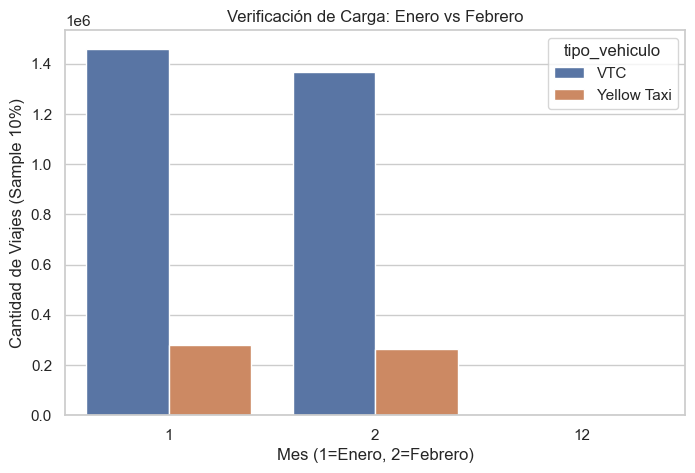

In [12]:
# Distribución temporal
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(data=df_anual, x='mes_num', hue='tipo_vehiculo')
plt.title("Verificación de Carga: Enero vs Febrero")
plt.xlabel("Mes (1=Enero, 2=Febrero)")
plt.ylabel("Cantidad de Viajes (Sample 10%)")
plt.show()